In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install nbformat

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
import matplotlib.pyplot as plt



In [5]:
df = pd.read_csv('ForeignGifts_edu.csv')
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


Describe the differences between different classes of gift types.

In [6]:
df["Gift Type"].value_counts()

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

Real estate: The donor gives land to the school
Contract: The donor and the school have an agreement
Monetary Gift: The donor give money directly to the school

**Which country gives the most money, in total?**

In [7]:
df[["Country of Giftor","Foreign Gift Amount"]].groupby(["Country of Giftor"]).sum().sort_values(by="Foreign Gift Amount", ascending=False)

,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
...,...
IRAN,80
ST. LUCIA,50
CROATIA,26


The country that gives the most money is Qatar.

**Which country initiates the most gifts by count?**

In [8]:
df[["Country of Giftor","Foreign Gift Amount"]].groupby(["Country of Giftor"]).count().sort_values(by="Foreign Gift Amount", ascending=False)

,Foreign Gift Amount
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
...,...
ST. LUCIA,1
TOKELAU,1
SLOVAKIA,1


The country that initiate the most gifts is England.

**Which country gives the largest gifts on average?**

In [9]:
df[["Country of Giftor","Foreign Gift Amount"]].groupby(["Country of Giftor"]).mean().sort_values(by="Foreign Gift Amount", ascending=False)

,Foreign Gift Amount
Country of Giftor,
BERMUDA,7.688837e+06
ECUADOR,3.985140e+06
QATAR,3.905109e+06
ANTIGUA,3.435545e+06
JERSEY,3.064589e+06
...,...
ST. LUCIA,5.000000e+01
IRAN,4.000000e+01
CROATIA,2.600000e+01


The country that gives the largest gifts on average is Bermuda

**Which institution receive the most money in total?**

<Axes: ylabel='Institution Name'>

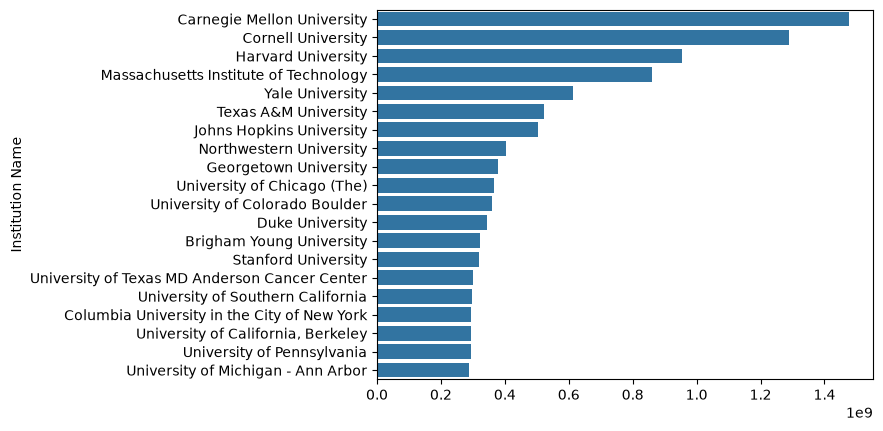

In [10]:
top20 = df.groupby("Institution Name")["Foreign Gift Amount"].sum().nlargest(20)
sns.barplot(x= top20.values, y= top20.index)
#df[["Institution Name","Foreign Gift Amount"]].groupby(["Institution Name"]).sum().sort_values(by="Foreign Gift Amount", ascending=False)

Carnegie Mellon University is the institution that receives the most money with a total of $1477922504


The following code chunk is used for analysis. Explanation provided in the docx.

In [26]:
country_counts = (
	df[df["Institution Name"].isin(top20.index)]
	.groupby("Institution Name")["Country of Giftor"]
	.nunique()
	.reset_index(name="Number of Countries")
)

top_20_with_country_counts = (
	top20.rename("Total Foreign Gift Amount")
	.rename_axis("Institution Name")
	.reset_index()
	.merge(country_counts, on="Institution Name")
)

top_20_with_country_counts

,Institution Name,Total Foreign Gift Amount,Number of Countries
0,Carnegie Mellon University,1477922504,30
1,Cornell University,1289937761,42
2,Harvard University,954803610,59
3,Massachusetts Institute of Technology,859071692,53
4,Yale University,613441311,43
5,Texas A&M University,521455050,8
6,Johns Hopkins University,502409595,115
7,Northwestern University,402316221,28
8,Georgetown University,379950511,21
9,University of Chicago (The),364544338,33


**Which institution receive the greatest number of gifts by count**

<Axes: ylabel='Institution Name'>

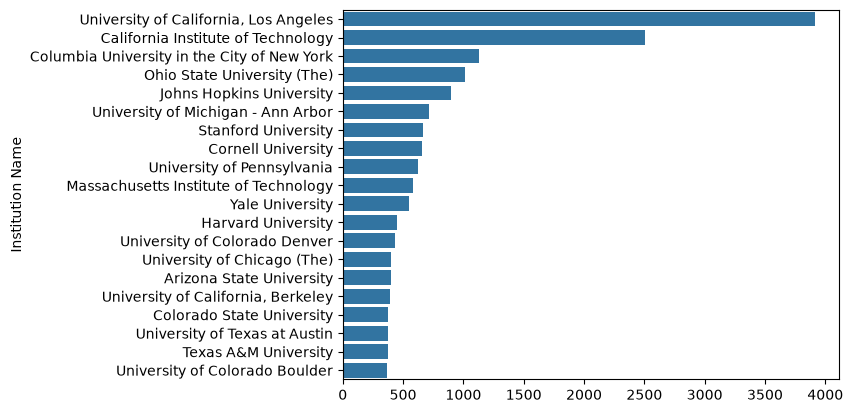

In [11]:
top_20_institutions = df.groupby("Institution Name")["Foreign Gift Amount"].count().nlargest(20)
sns.barplot(x= top_20_institutions.values, y= top_20_institutions.index)
#df[["Institution Name","Foreign Gift Amount"]].groupby(["Institution Name"]).count().sort_values(by="Foreign Gift Amount", ascending=False).head(10)

The instituition that receives the greatest number of gifts is UCLA.

**What is the average amount each university receives? Median amount? If they are different why?**

<Axes: xlabel='Foreign Gift Amount', ylabel='Count'>

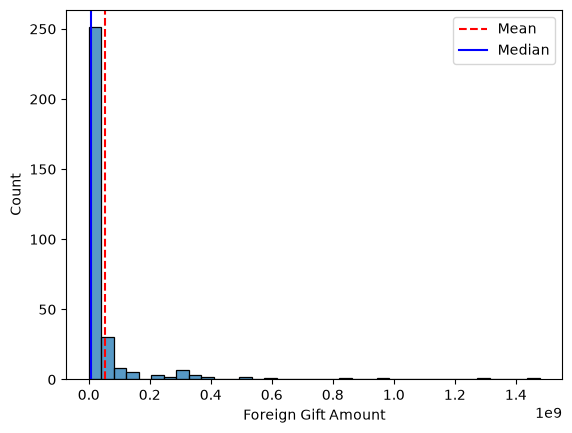

In [12]:
#I used chatgpt to help me plot the median and mean as veritcal lines
total_amount = df.groupby("Institution Name")["Foreign Gift Amount"].sum()
#median and mean
mean = total_amount.mean()
median = total_amount.median()

plt.axvline(mean, linestyle="--", label="Mean", color="red")
plt.axvline(median, linestyle="-", label="Median", color="blue")

plt.legend()

#plot histogram 
sns.histplot(total_amount)

In [17]:
#overall mean
mean


np.float64(52202878.974842764)

The histogram shows that the distribution of total foreign gifts received by universities is highly right-skewed. The mean is considerably higher than the median because a small number of universities received extremely large gifts. Therefore, the median better represents the typical amount received by a university.

**What is the largest flow of a single country to a single institution?**

In [19]:
pd.crosstab(df["Country of Giftor"],df["Institution Name"]).T

Country of Giftor,AFGHANISTAN,AMERICAN SAMOA,ANGOLA,ANTIGUA,ARGENTINA,ARMENIA,AUSTRALIA,AUSTRIA,AZERBAIJAN,BAHAMAS,...,UNITED NATIONS,URUGUAY,USA,VENEZUELA,VIETNAM,VIRGIN ISLANDS (BRITISH),WALES,YEMEN,ZAMBIA,ZIMBABWE
Institution Name,,,,,,,,,,,,,,,,,,,,,
Adelphi University,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Albert Einstein College of Medicine,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alfred University,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
American University (The),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Amherst College,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wright State University,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Xavier University of Louisiana,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Yale University,0,0,0,0,0,0,5,1,0,0,...,0,0,0,0,0,2,0,0,0,1


The largest flow of a single country to a single instituition is Qatar to Cornell University with $1018473315.

**Which are the top giftors to US academic institutions?**

In [15]:
import nbformat
print(nbformat.__version__)

5.11.1


In [16]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()